## Parâmetros Globais e Importações

Os dados foram gerados a partir do modelo:
$$Y_i = \beta_0 + \beta_1 X_i + \epsilon_i$$
onde $\beta_0 = 1$, $\beta_1 = 2$, $X_i \sim \text{Uniforme}(0,10)$ e os cenários alteram apenas um componente por vez: a distribuição dos erros, a média condicional, a dependência serial ou a forma funcional.

As medidas usadas na análise incluem viés, média do estimador, variância, MSE, cobertura, tamanho do teste e poder. O cenário clássico é a referência para todas as comparações.

In [1]:
# seed: int = 20260506
# replications: int = 1000
# sample_sizes: list[int] = field(default_factory=lambda: [30, 100])
# alpha: float = 0.05

# beta0: float = 1.0
# beta1: float = 2.0
# sigma: float = 1.0

# x_low: float = 0.0
# x_high: float = 10.0

# t_df: int = 3
# gamma_shape: float = 2.0
# gamma_scale: float = 1.0
# delta_const: float = 1.0
# delta_x: float = 0.6
# ar1_rho: float = 0.7
# lognormal_sigma: float = 0.4

In [ ]:
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
output_dir = r'E:\MYAREA\AREA_DEV\Faculdade\ModelosRegressaoI\EstudoDeSimulacao'
df_compact = pd.read_csv(f'{output_dir}\\outputs\\tables\\resumo_compacto.csv') 
df_metrics = pd.read_csv(f'{output_dir}\\outputs\\tables\\resumo_metricas.csv')

## Cenário 1: Modelo Clássico Normal

In [13]:
# Comparação Direta: C1 (Normal) para beta1 (n=30 e n=100)
cenarios_interesse = ["C1_classico_normal"]
df_c1 = df_metrics[
    (df_metrics["scenario_label"].isin(cenarios_interesse)) & 
    (df_metrics["model"] == "original_scale")
]

# Exibir a tabela focada nas métricas de estabilidade e inferência
display(df_c1[["scenario_label", "parameter", "n", "mean_hat", "bias", "variance", "mse", "coverage", "size_h0", "power_h1"]])

,scenario_label,parameter,n,mean_hat,bias,variance,mse,coverage,size_h0,power_h1
4,C1_classico_normal,beta0,30,0.979994,-0.020006,0.140086,0.140347,0.935,NaN,NaN
5,C1_classico_normal,beta1,30,2.003081,0.003081,0.004391,0.004397,0.950,0.051,1.0
6,C1_classico_normal,beta0,100,1.002656,0.002656,0.044675,0.044637,0.957,NaN,NaN
7,C1_classico_normal,beta1,100,1.999951,-0.000049,0.001210,0.001209,0.958,0.052,1.0


### Etapas

#### Estimação:
- **Média do Estimador**: A média dos valores estimados para os parâmetros estão próximos do valor verdadeiro, indicando que o estimador é não-viesado.
- **Viés**: O viés está próximo de zero, indicando que o estimador é não-viesado, ou seja, em média, ele acerta o valor verdadeiro do parâmetro.
- **Variância**: A variância dos parâmetros diminuem à medida que o tamanho da amostra aumenta, o que é esperado, pois mais dados geralmente levam a estimativas mais precisas.
- **MSE (Erro Quadrático Médio)**: O MSE é baixo, indicando que o estimador tem um bom desempenho geral.

In [14]:
display(df_c1[["parameter", "n", "mean_hat", "bias", "variance", "mse"]])

,parameter,n,mean_hat,bias,variance,mse
4,beta0,30,0.979994,-0.020006,0.140086,0.140347
5,beta1,30,2.003081,0.003081,0.004391,0.004397
6,beta0,100,1.002656,0.002656,0.044675,0.044637
7,beta1,100,1.999951,-0.000049,0.001210,0.001209


#### Inferência e Testes:
- **Cobertura**: A cobertura dos intervalos de confiança está próxima do nível nominal (95%), indicando que os intervalos estão bem calibrados.
- **Tamanho do Teste (Size)**: O tamanho do teste - erro do tipo I - para a hipótese nula está próximo do nível de significância (5%), indicando que o teste não é excessivamente conservador
- **Poder do Teste (Power)**: O poder do teste para a hipótese alternativa é 100%, pois o valor verdadeiro do parâmetro está longe do valor sob a hipótese nula, facilitando a rejeição correta da hipótese nula.

In [15]:
display(df_c1[[ "parameter", "n", "coverage", "size_h0", "power_h1"]])

,parameter,n,coverage,size_h0,power_h1
4,beta0,30,0.935,NaN,NaN
5,beta1,30,0.950,0.051,1.0
6,beta0,100,0.957,NaN,NaN
7,beta1,100,0.958,0.052,1.0


#### Diagnóstico e Correção:
- **QQ-Plot dos Resíduos**: O QQ-Plot dos resíduos mostra que eles seguem aproximadamente uma linha reta, indicando que os resíduos estão próximos de uma distribuição normal, o que é uma suposição importante para a validade dos testes de hipóteses e intervalos de confiança.
- **Resíduos vs Ajustados**: O gráfico de resíduos vs ajustados não mostra padrões evidentes, sugerindo que a relação linear é adequada e que a variância dos resíduos é constante (homocedasticidade).

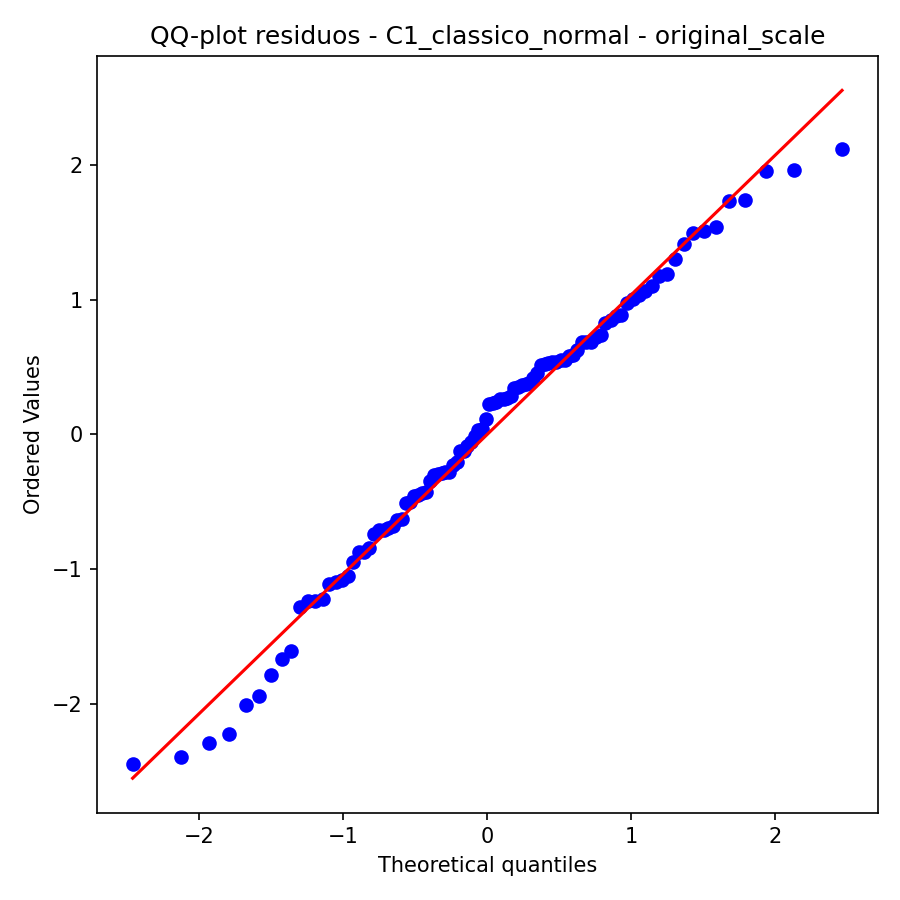

In [16]:
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_qqplot_residuos.png'))

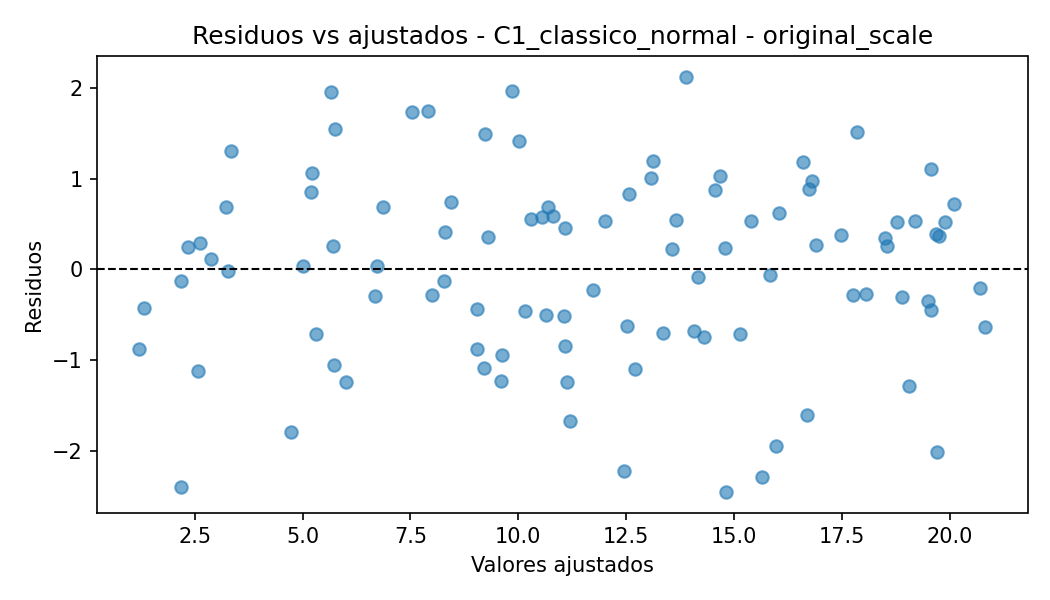

In [17]:
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_residuos_vs_ajustados.png'))

## Cenário 2: Erros com Curtose Elevada (Caudas Pesadas)

Neste cenário, a premissa de normalidade dos erros foi violada utilizando uma distribuição t de Student com 3 graus de liberdade, escalonada para manter a mesma variância do Cenário 1. O objetivo é avaliar a robustez do MQO sob maior probabilidade de ocorrência de valores extremos no termo de erro.

In [27]:
# Comparação Direta: C1 (Normal) vs C2 (Caudas Pesadas) para beta1 (n=30 e n=100)
cenarios_interesse = ["C1_classico_normal", "C2_caudas_pesadas"]
df_c2 = df_metrics[
    (df_metrics["scenario_label"].isin(cenarios_interesse)) & 
    (df_metrics["parameter"] == "beta1") &
    (df_metrics["model"] == "original_scale")
]

# Exibir a tabela focada nas métricas de estabilidade e inferência
display(df_c2[["scenario_label", "n", "bias", "variance", "mse", "coverage", "size_h0", "power_h1"]])

,scenario_label,n,bias,variance,mse,coverage,size_h0,power_h1
5,C1_classico_normal,30,0.003081,0.004391,0.004397,0.950,0.051,1.0
7,C1_classico_normal,100,-0.000049,0.001210,0.001209,0.958,0.052,1.0
17,C2_caudas_pesadas,30,0.001375,0.003824,0.003822,0.958,0.055,1.0
19,C2_caudas_pesadas,100,-0.001713,0.001289,0.001291,0.946,0.040,1.0


### Avaliação

#### Estabilidade dos Estimadores
- Comparando as métricas de variância (`variance`) e Erro Quadrático Médio (`mse`), o MSE continua não-enviesado. A cauda pesada, sozinha, não o torna enviesado.
- O viés (`bias`) está próximo de zero em ambos.
- Como a variância dos erros foi normalizada, a variância dos estimadores é próxima à do Cenário 1, mas com maior instabilidade por causa de valores extremos.
- A média dos estimadores (`mean_hat`) está próxima do valor verdadeiro, indicando que o estimador é não-viesado mesmo com erros de caudas pesadas.

In [32]:
display(df_c2[["scenario_label", "n", "mean_hat", "bias", "variance", "mse"]])

,scenario_label,n,mean_hat,bias,variance,mse
5,C1_classico_normal,30,2.003081,0.003081,0.004391,0.004397
7,C1_classico_normal,100,1.999951,-0.000049,0.001210,0.001209
17,C2_caudas_pesadas,30,2.001375,0.001375,0.003824,0.003822
19,C2_caudas_pesadas,100,1.998287,-0.001713,0.001289,0.001291


#### Presença de Observações Influentes
A distribuição $t$ com poucos graus de liberdade aumenta a probabilidade de erros extremos. Quando um *outlier* ocorre nas pontas da distribuição de $X$, ele exerce alta alavancagem, puxando a reta de regressão e gerando estimativas pontuais discrepantes em algumas repetições da simulação. 

Isso pode ser visualizado nos Boxplots e Histogramas, onde o Cenário 2 apresenta maior quantidade de valores extremos para $\hat{\beta}_1$ em comparação ao modelo clássico.

Boxplot Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)


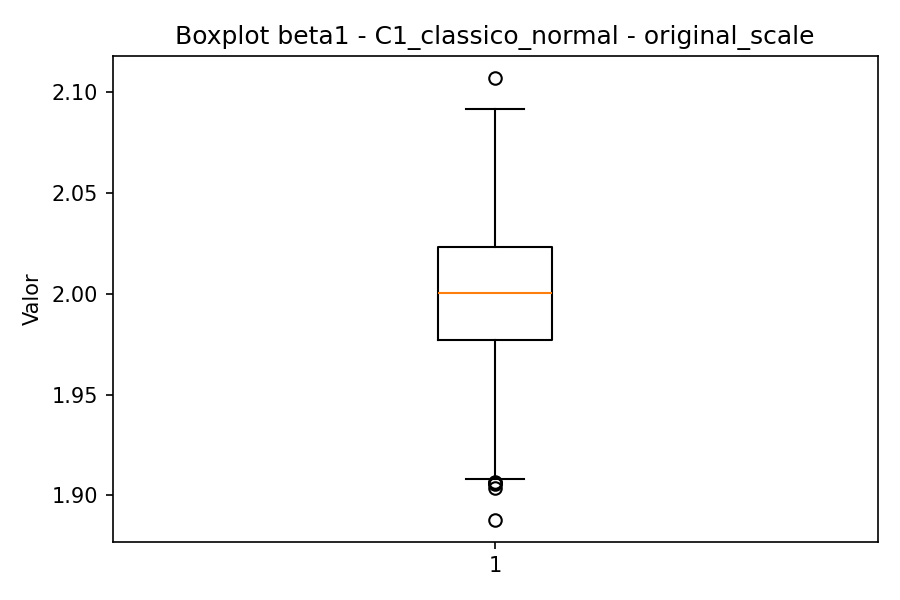

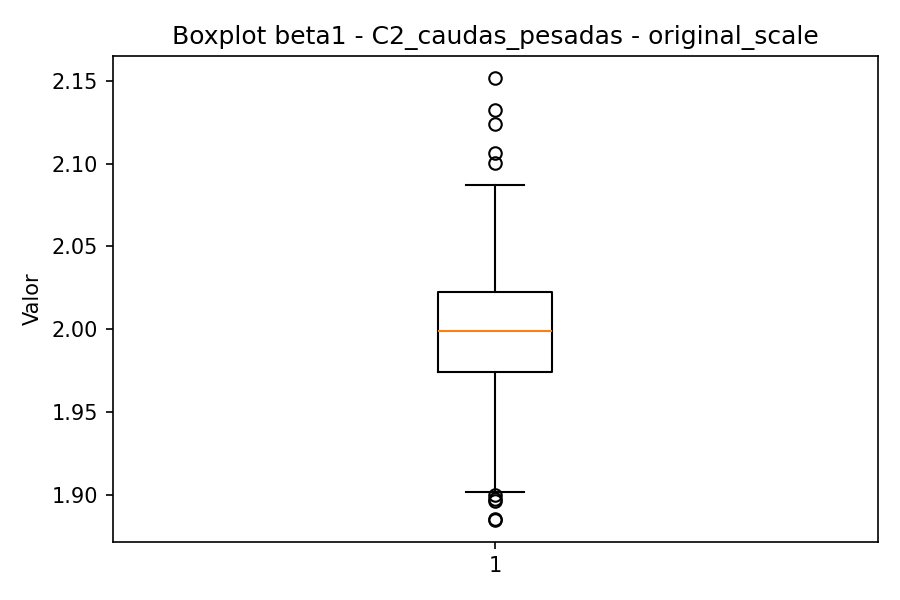

Histograma Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)


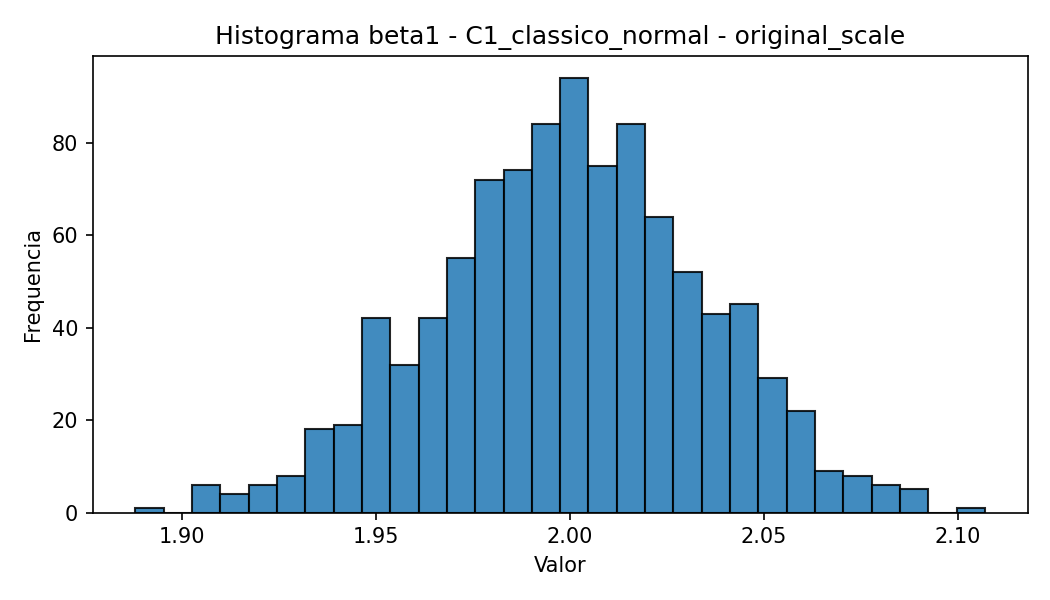

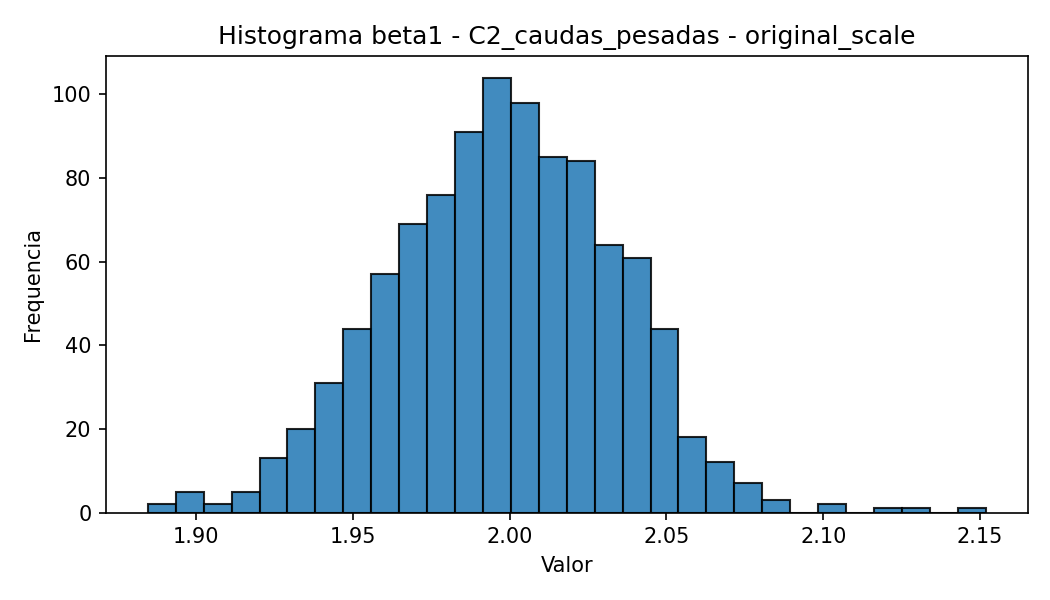

In [23]:
# Célula de Código para exibir as imagens já salvas (usando IPython.display)
print("Boxplot Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_boxplot_beta1.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_boxplot_beta1.png'))

print("Histograma Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_hist_beta1.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_hist_beta1.png'))

#### Impacto sobre Intervalos de Confiança e Testes
Apesar da quebra de normalidade, a taxa de cobertura dos intervalos de confiança (`coverage`) para $\hat{\beta}_1$ no Cenário 2 manteve-se muito próxima da taxa nominal de $95\%$, tanto para $n=30$ quanto para $n=100$. 

A taxa de rejeição sob $H_0$ (`size_h0`) também se manteve controlada próxima de $\alpha = 0.05$, e o poder do teste (`power_h1`) foi mantido. Isso evidencia a robustez do MQO: devido ao Teorema Central do Limite, a distribuição amostral dos estimadores aproxima-se da normalidade mesmo quando os erros originais têm caudas pesadas, garantindo a validade da inferência assintótica.

In [24]:
display(df_c2[["scenario_label", "n", "coverage", "size_h0", "power_h1"]])

,scenario_label,n,coverage,size_h0,power_h1
5,C1_classico_normal,30,0.950,0.051,1.0
7,C1_classico_normal,100,0.958,0.052,1.0
17,C2_caudas_pesadas,30,0.958,0.055,1.0
19,C2_caudas_pesadas,100,0.946,0.040,1.0


### Etapas

#### Diagnóstico e Correção:
- **QQ-Plot dos Resíduos**: O QQ-Plot dos resíduos mostra que eles seguem aproximadamente uma linha reta, porém com maior dispersão nas caudas, indicando que os resíduos estão próximos de uma distribuição normal, mas com maior probabilidade de valores extremos, o que é consistente com a distribuição t utilizada.
- **Resíduos vs Ajustados**: O gráfico de resíduos vs ajustados não mostra padrões evidentes, entretanto, a dispersão dos resíduos reflete a presença de valores extremos, efeito da distribuição t.
- **Correção**: Para os valores extremos, tranformações como logaritmo poderiam ser consideradas para mitigar o impacto dos outliers, mas neste cenário, o MQO mostrou-se resiliente mesmo sem correção.

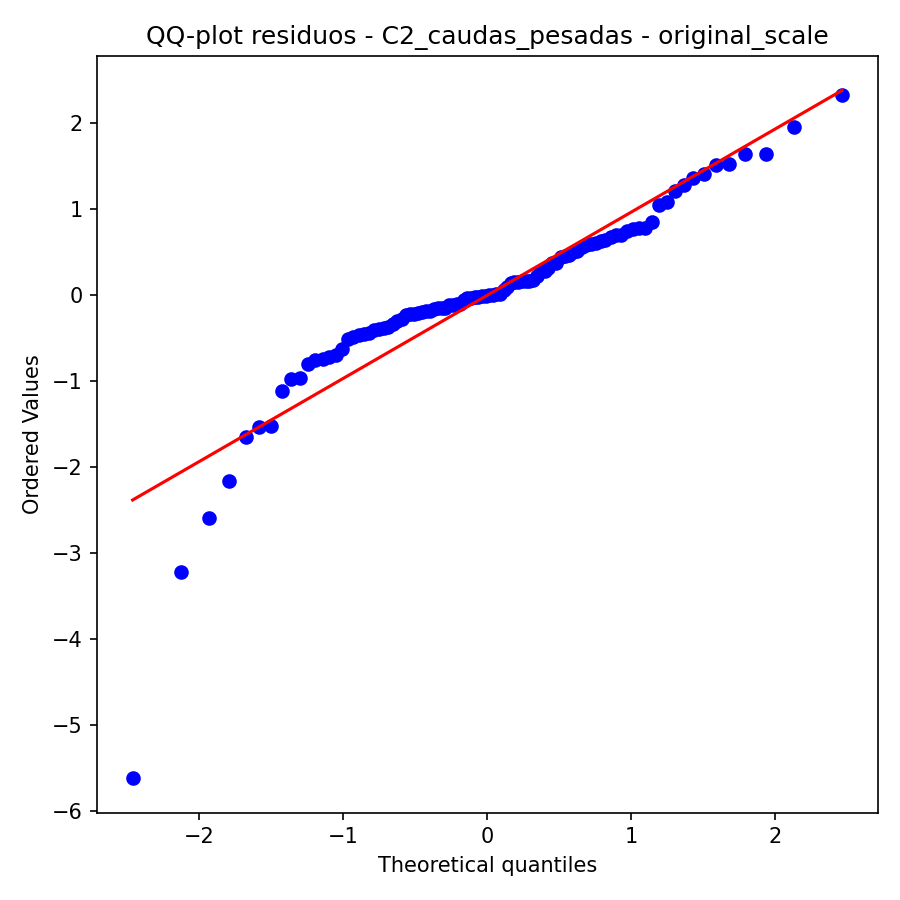

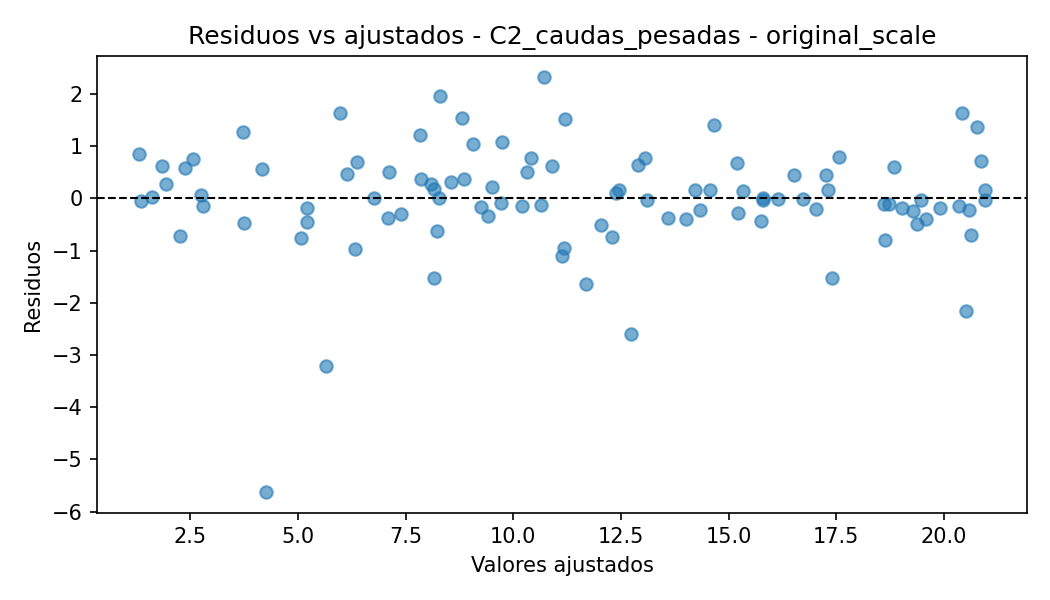

In [35]:
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_qqplot_residuos.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_residuos_vs_ajustados.png'))

## Cenário 3: Erros com Assimetria (Distribuição Gamma)

Neste cenário, investigamos o impacto de erros que não seguem uma distribuição simétrica. Utilizamos uma distribuição Gamma centralizada e padronizada para garantir que $E[\epsilon] = 0$, mas mantendo a assimetria característica (skewness). O objetivo é verificar se a falta de simetria desloca o estimador ou invalida os testes de hipótese.

In [116]:
# Comparação: C1 (Normal) vs C3 (Assimétrico) para beta1
cenarios_interesse = ["C1_classico_normal", "C3_erros_assimetricos"]
df_c3 = df_metrics[
    (df_metrics["scenario_label"].isin(cenarios_interesse)) & 
    (df_metrics["parameter"] == "beta1")
]

display(df_c3[["scenario_label", "n", "bias", "variance", "mse", "coverage", "size_h0"]])

,scenario_label,n,bias,variance,mse,coverage,size_h0
5,C1_classico_normal,30,0.003081,0.004391,0.004397,0.950,0.051
7,C1_classico_normal,100,-0.000049,0.001210,0.001209,0.958,0.052
29,C3_erros_assimetricos,30,0.001190,0.005457,0.005453,0.947,0.050
31,C3_erros_assimetricos,100,0.002289,0.001447,0.001451,0.943,0.048


### Avaliação
#### Forma da Distribuição dos Estimadores
Mesmo com erros fortemente assimétricos, o **viés empírico** observado na tabela permanece próximo de zero. Isso confirma a teoria de que o MQO exige apenas que os erros tenham média zero para serem não-viesados, independentemente da simetria da distribuição. 



Ao observar o histograma de $\hat{\beta}_1$ para $n=30$, notamos que a distribuição do estimador já se assemelha a uma Normal, ilustrando o efeito do Teorema Central do Limite em suavizar a assimetria original dos dados.

Histograma de Beta 1 - Erros Assimétricos (n=30)


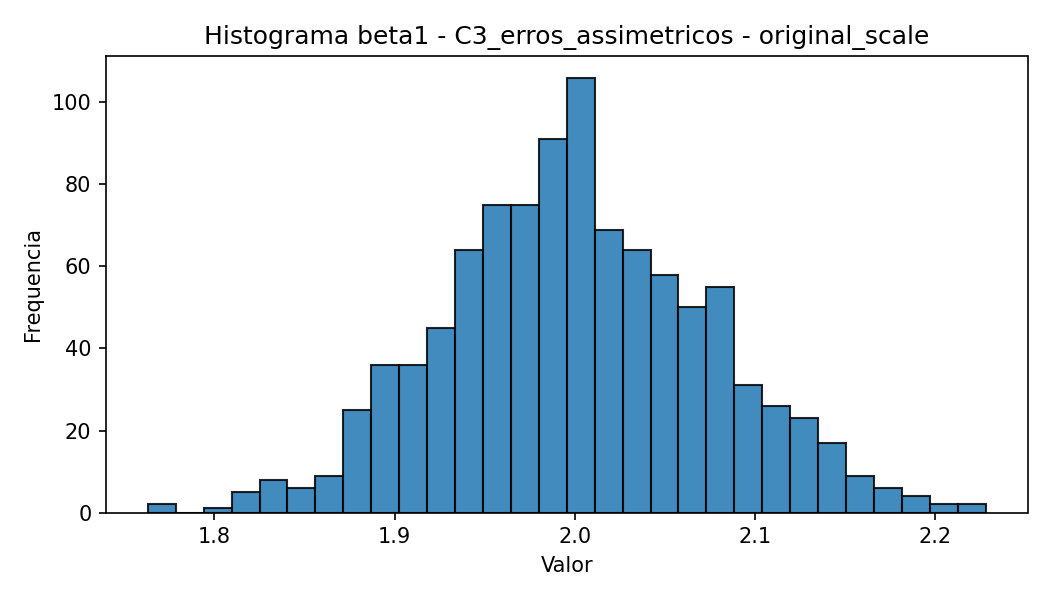

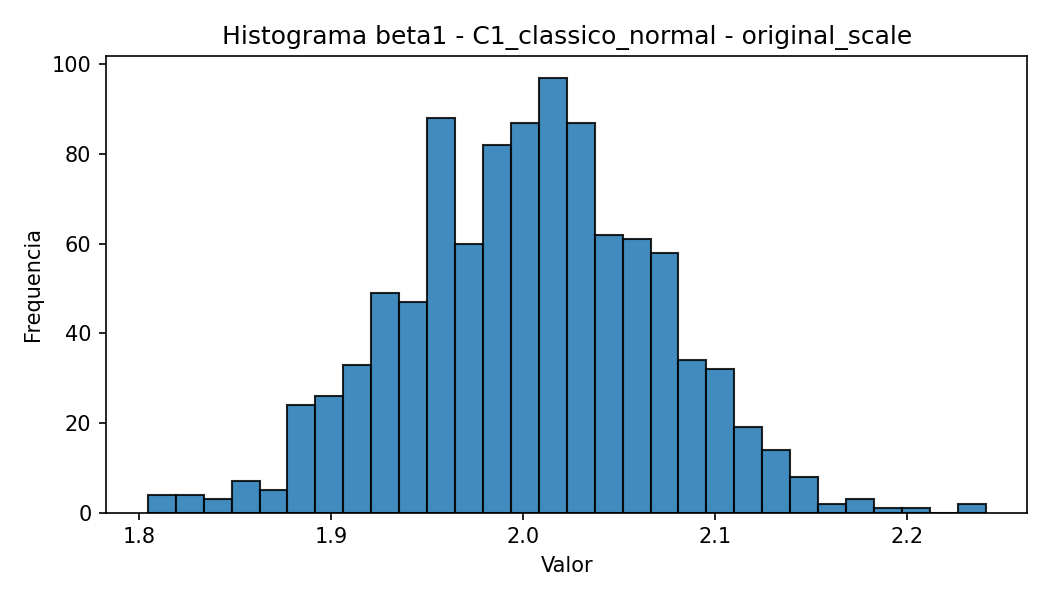

Histograma de Beta 1 - Erros Assimétricos (n=100)


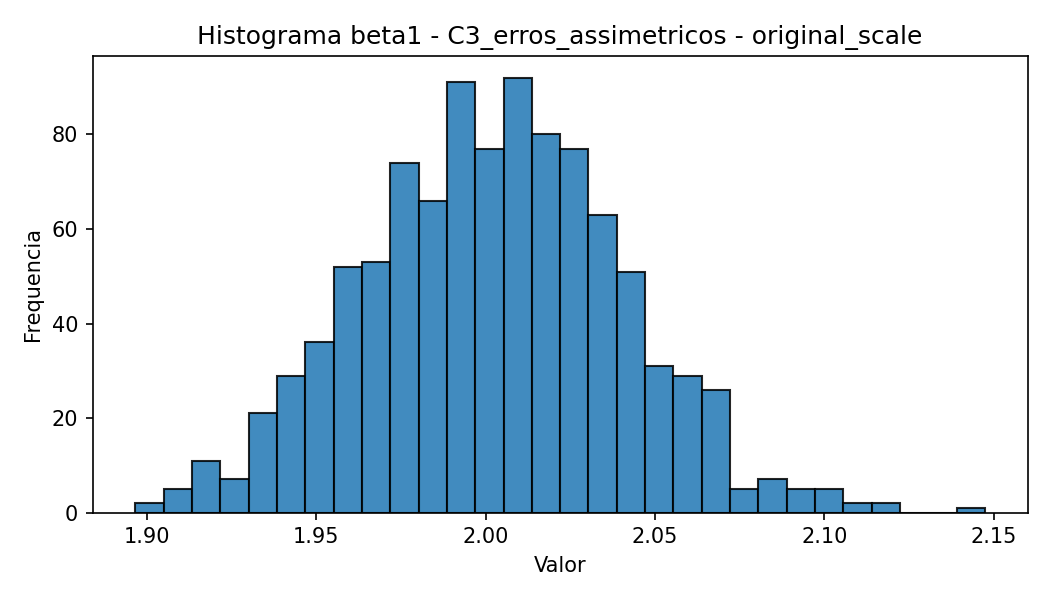

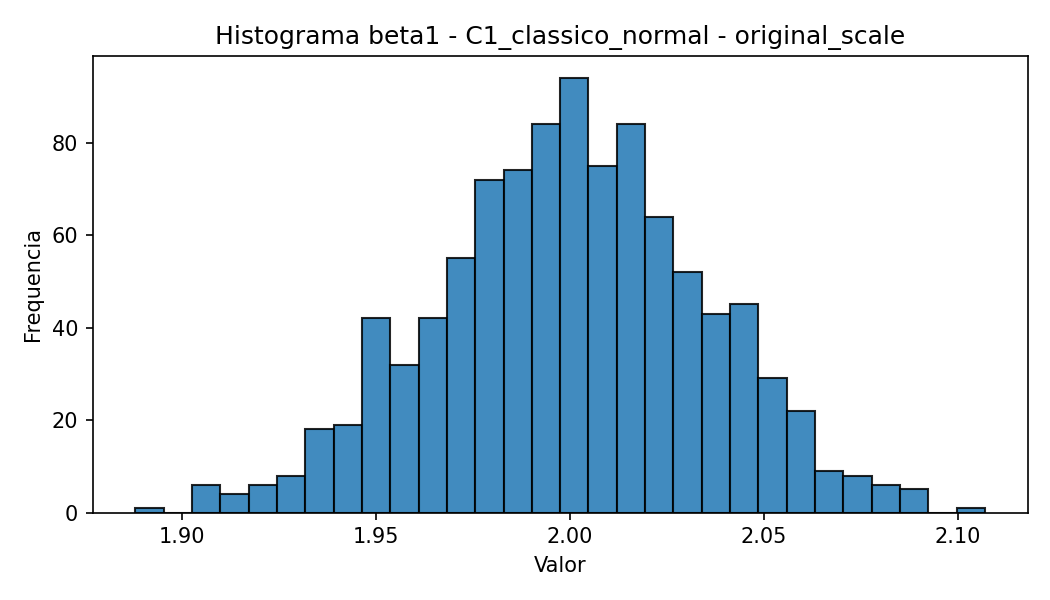

In [43]:
print("Histograma de Beta 1 - Erros Assimétricos (n=30)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C3_erros_assimetricos_n30_original_scale_hist_beta1.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n30_original_scale_hist_beta1.png'))

print("Histograma de Beta 1 - Erros Assimétricos (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C3_erros_assimetricos_n100_original_scale_hist_beta1.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_hist_beta1.png'))

#### Comportamento do QQ-Plot
- Diferente do cenário clássico, o QQ-plot dos resíduos para o Cenário 3 apresenta uma curvatura sistemática. Essa "barriga" no gráfico indica que os quantis empíricos não coincidem com os quantis da Normal teórica, denunciando a assimetria positiva (cauda longa à direita) da distribuição Gamma utilizada.
- **Resíduos vs Ajustados**: O gráfico de resíduos vs ajustados para o Cenário 3 mostra um valores dispersos, especialmente para os resíduos positivos, refletindo a assimetria dos erros. No entanto, não há um padrão claro de heterocedasticidade, sugerindo que a variância dos resíduos é relativamente constante.

QQ-Plot dos Resíduos - Cenário Assimétrico (n=100)


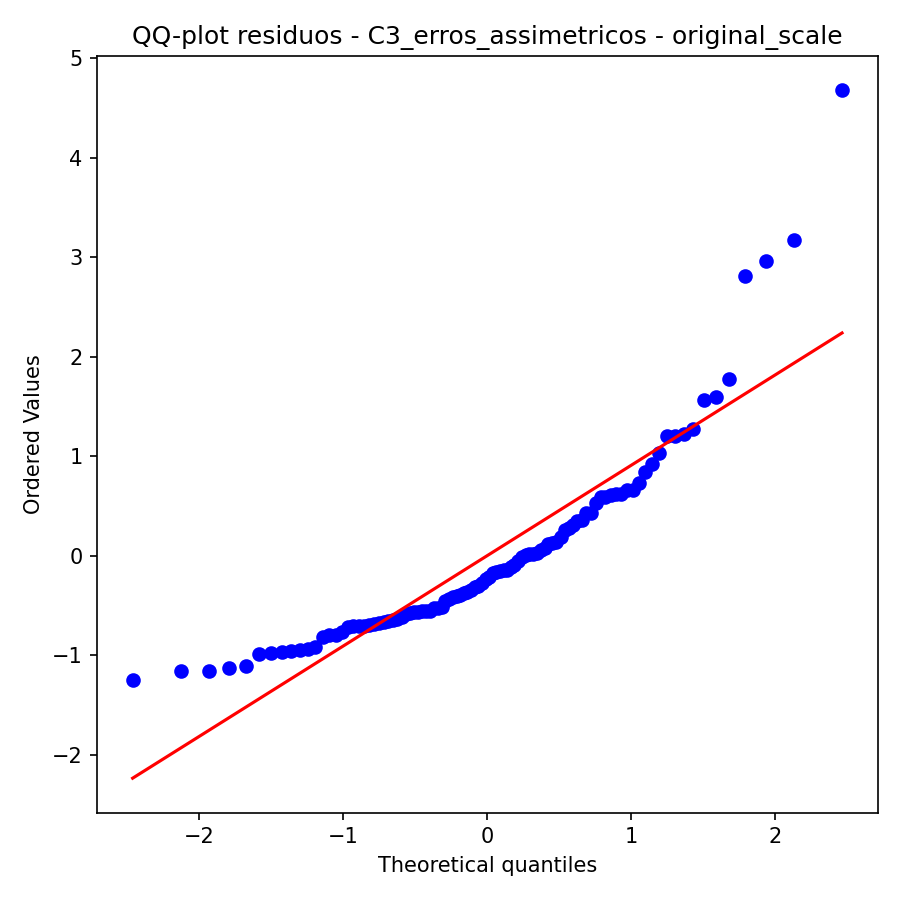

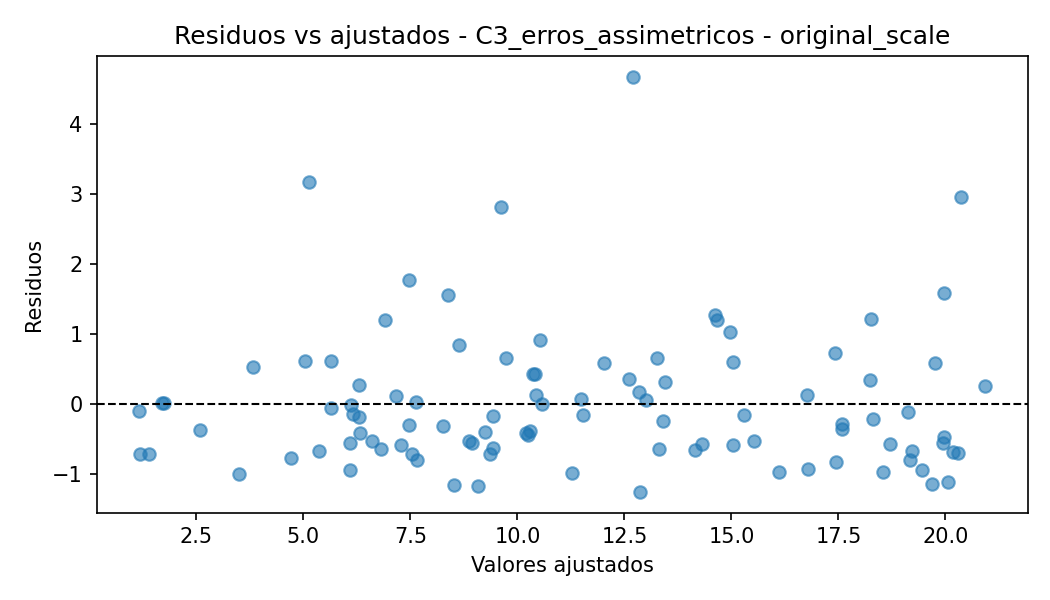

In [29]:
print("QQ-Plot dos Resíduos - Cenário Assimétrico (n=100)")
display(Image(filename=f'{output_dir}//outputs//figures//C3_erros_assimetricos_n100_original_scale_qqplot_residuos.png'))
display(Image(filename=f'{output_dir}//outputs//figures//C3_erros_assimetricos_n100_original_scale_residuos_vs_ajustados.png'))

#### Distorções na Inferência
A taxa de cobertura (`coverage`) para $n=100$ aproxima-se de 95%, sugerindo que a inferência assintótica é válida. Entretanto, para $n=30$, podemos observar uma leve queda na cobertura. Isso ocorre porque, em amostras pequenas, a aproximação normal do estimador ainda carrega parte da "herança" da assimetria dos erros, o que pode tornar os p-valores ligeiramente imprecisos.

In [44]:
df_c3[["scenario_label", "n", "coverage", "size_h0"]]

,scenario_label,n,coverage,size_h0
5,C1_classico_normal,30,0.950,0.051
7,C1_classico_normal,100,0.958,0.052
29,C3_erros_assimetricos,30,0.947,0.050
31,C3_erros_assimetricos,100,0.943,0.048


### Etapas

#### Estimação:
- **Média do Estimador**: ainda próximo do valor verdadeiro, indicando que o estimador é não-viesado.
- **Viés**: próximo de zero, indicando que o estimador é não-viesado.
- **Variância**: a variância dos estimadores é maior do que no cenário clássico, refletindo a maior dispersão causada pela assimetria dos erros.
- **MSE (Erro Quadrático Médio)**: o MSE é maior do que no cenário clássico, indicando que o estimador tem um desempenho inferior em termos de precisão.

In [52]:
display(df_c3[["scenario_label", "n", "mean_hat", "bias", "variance", "mse"]])

,scenario_label,n,mean_hat,bias,variance,mse
5,C1_classico_normal,30,2.003081,0.003081,0.004391,0.004397
7,C1_classico_normal,100,1.999951,-0.000049,0.001210,0.001209
29,C3_erros_assimetricos,30,2.001190,0.001190,0.005457,0.005453
31,C3_erros_assimetricos,100,2.002289,0.002289,0.001447,0.001451


#### Inferência e Testes:
- **Cobertura**: A cobertura dos intervalos de confiança está próxima do nível nominal (95%), indicando que os intervalos estão bem calibrados. Mas com uma leve queda devido à assimetria dos erros.
- **Tamanho do Teste (Size)**: O tamanho do teste - erro do tipo I - para a hipótese nula está próximo do nível de significância (5%), indicando que o teste não é excessivamente conservador. 
- **Poder do Teste (Power)**: O poder do teste para a hipótese alternativa é 100%, pois o valor verdadeiro do parâmetro está longe do valor sob a hipótese nula, facilitando a rejeição correta da hipótese nula.

In [55]:
display(df_c3[["scenario_label", "n", "coverage", "size_h0", "power_h1"]])

,scenario_label,n,coverage,size_h0,power_h1
5,C1_classico_normal,30,0.950,0.051,1.0
7,C1_classico_normal,100,0.958,0.052,1.0
29,C3_erros_assimetricos,30,0.947,0.050,1.0
31,C3_erros_assimetricos,100,0.943,0.048,1.0


#### Correções
- Transformações como logaritmo ou Box-Cox poderiam ser consideradas para mitigar a assimetria dos erros, mas mesmo sem correção, o MQO mostrou-se relativamente robusto, especialmente para amostras maiores.

## Cenário 4: Erros com Média Diferente de Zero

Neste módulo, comparamos duas violações da hipótese $E[\epsilon|X] = 0$:
1. **C4a (Média Constante):** O erro tem uma média fixa $\mu_{\epsilon} \neq 0$.
2. **C4b (Endogeneidade):** O erro é correlacionado com a variável explicativa ($E[\epsilon|X] \neq 0$), simulado como $\epsilon_i = \delta X_i + u_i$.

In [64]:
# Filtrando os dados para os dois sub-cenários do Cenário 4
cenarios_c4 = ["C1_classico_normal", "C4a_media_erro_nao_nula_constante", "C4b_media_erro_dependente_X"]
df_c4 = df_metrics[df_metrics["scenario_label"].isin(cenarios_c4)]

# Organizando para facilitar a comparação visual entre beta0 e beta1
display(df_c4.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter", "mean_hat", "bias", "variance", 'mse', "coverage", "size_h0"]])

,scenario_label,n,parameter,mean_hat,bias,variance,mse,coverage,size_h0
4,C1_classico_normal,30,beta0,0.979994,-0.020006,0.140086,0.140347,0.935,NaN
5,C1_classico_normal,30,beta1,2.003081,0.003081,0.004391,0.004397,0.950,0.051
6,C1_classico_normal,100,beta0,1.002656,0.002656,0.044675,0.044637,0.957,NaN
7,C1_classico_normal,100,beta1,1.999951,-0.000049,0.001210,0.001209,0.958,0.052
20,C4a_media_erro_nao_nula_constante,30,beta0,2.004214,1.004214,0.100125,1.108470,0.132,NaN
21,C4a_media_erro_nao_nula_constante,30,beta1,1.999764,-0.000236,0.005061,0.005056,0.948,0.048
22,C4a_media_erro_nao_nula_constante,100,beta0,1.989550,0.989550,0.050480,1.029638,0.002,NaN
23,C4a_media_erro_nao_nula_constante,100,beta1,2.001228,0.001228,0.001334,0.001334,0.950,0.048
24,C4b_media_erro_dependente_X,30,beta0,1.009759,0.009759,0.111220,0.111204,0.950,NaN
25,C4b_media_erro_dependente_X,30,beta1,2.599022,0.599022,0.003505,0.362329,0.000,1.000


### Impacto sobre os Estimadores e Presença de Viés
Neste cenário, a comparação com o clássico deve ser feita em duas leituras separadas, porque cada subcenário altera apenas um aspecto do processo gerador:
1. C4a (Média constante):
   1. Apenas a média do erro é deslocada. O intercepto absorve essa mudança e passa a apresentar viés, enquanto a inclinação permanece muito próxima do cenário clássico.
   2. O efeito é mais claro em n=100, porque a estimativa fica mais estável e o desvio do intercepto aparece com menos ruído amostral.
2. C4b (Dependente de X):
   1. Apenas a condição E[\epsilon|X]=0 é violada. O problema passa para o coeficiente angular, que fica enviesado e inconsistente.
   2. A comparação com C1 mostra que a diferença relevante não é de forma funcional, mas de endogeneidade.

,scenario_label,n,parameter,mean_hat,bias,variance,mse
4,C1_classico_normal,30,beta0,0.979994,-0.020006,0.140086,0.140347
5,C1_classico_normal,30,beta1,2.003081,0.003081,0.004391,0.004397
6,C1_classico_normal,100,beta0,1.002656,0.002656,0.044675,0.044637
7,C1_classico_normal,100,beta1,1.999951,-0.000049,0.001210,0.001209
20,C4a_media_erro_nao_nula_constante,30,beta0,2.004214,1.004214,0.100125,1.108470
21,C4a_media_erro_nao_nula_constante,30,beta1,1.999764,-0.000236,0.005061,0.005056
22,C4a_media_erro_nao_nula_constante,100,beta0,1.989550,0.989550,0.050480,1.029638
23,C4a_media_erro_nao_nula_constante,100,beta1,2.001228,0.001228,0.001334,0.001334
24,C4b_media_erro_dependente_X,30,beta0,1.009759,0.009759,0.111220,0.111204
25,C4b_media_erro_dependente_X,30,beta1,2.599022,0.599022,0.003505,0.362329


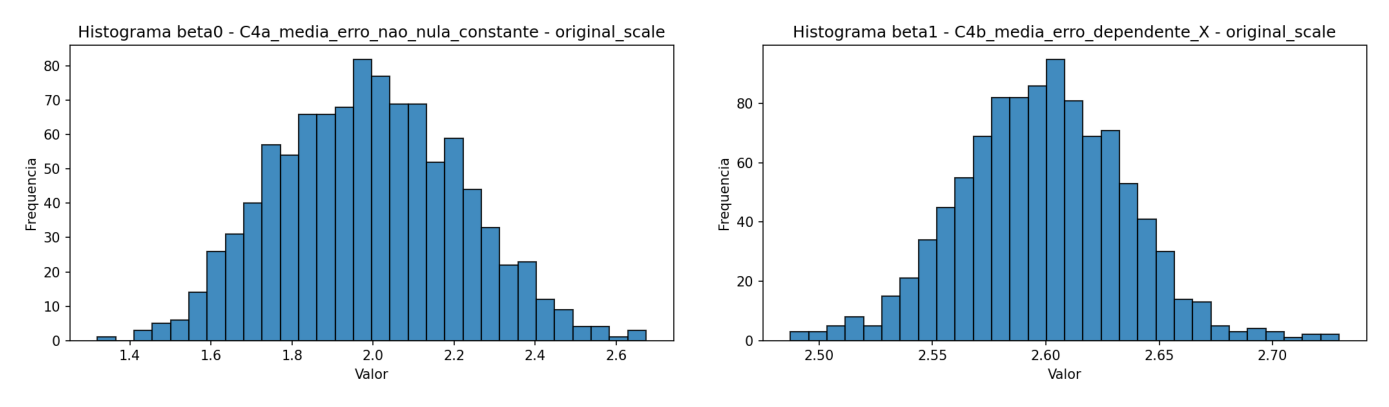

In [105]:
display(df_c4.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter", "mean_hat", "bias", "variance", 'mse']])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4a_media_erro_nao_nula_constante_n100_original_scale_hist_beta0.png'))
axes[0].axis('off')
axes[1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4b_media_erro_dependente_X_n100_original_scale_hist_beta1.png'))
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Validade da Inferência
Aqui a leitura deve separar claramente os dois subcenários e usar o clássico como referência:
1. No C4a:
   1. A cobertura do intercepto cai fortemente porque o erro tem média diferente de zero.
   2. A inclinação continua bem estimada e, por isso, sua cobertura permanece próxima da nominal.
   3. O efeito do tamanho amostral aparece na estabilidade das métricas: com n=100, a estimativa do viés e da cobertura fica mais nítida do que com n=30.
2. No C4b:
   1. A cobertura de beta1 se deteriora porque a endogeneidade contamina o coeficiente angular.
   2. O tamanho do teste fica distorcido e o poder calculado sob um modelo mal especificado deixa de ter interpretação confiável.
   3. A conclusão central é que o problema não é de distribuição marginal dos erros, mas de dependência entre X e o erro.

In [67]:
display(df_c4.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter","coverage", "size_h0", "power_h1"]])

,scenario_label,n,parameter,coverage,size_h0,power_h1
4,C1_classico_normal,30,beta0,0.935,NaN,NaN
5,C1_classico_normal,30,beta1,0.950,0.051,1.0
6,C1_classico_normal,100,beta0,0.957,NaN,NaN
7,C1_classico_normal,100,beta1,0.958,0.052,1.0
20,C4a_media_erro_nao_nula_constante,30,beta0,0.132,NaN,NaN
21,C4a_media_erro_nao_nula_constante,30,beta1,0.948,0.048,1.0
22,C4a_media_erro_nao_nula_constante,100,beta0,0.002,NaN,NaN
23,C4a_media_erro_nao_nula_constante,100,beta1,0.950,0.048,1.0
24,C4b_media_erro_dependente_X,30,beta0,0.950,NaN,NaN
25,C4b_media_erro_dependente_X,30,beta1,0.000,1.000,1.0


### Etapas

#### Diagnóstico e Correção:
- **Cenário 4a (Média não nula constante):** Como o modelo possui intercepto, o QQ-plot e o gráfico de resíduos vs ajustados podem parecer semelhantes ao cenário clássico. Isso não significa ausência de problema; o desvio foi absorvido pelo intercepto, então a falha aparece nas estimativas e na cobertura, não necessariamente no diagnóstico visual.
- **Cenário 4b (Endogeneidade):** O diagnóstico gráfico padrão é limitado para revelar a correlação entre X e o erro. Por isso, o foco deve ficar nas métricas de inferência: cobertura, tamanho do teste e estabilidade da estimativa de beta1 em comparação com C1.

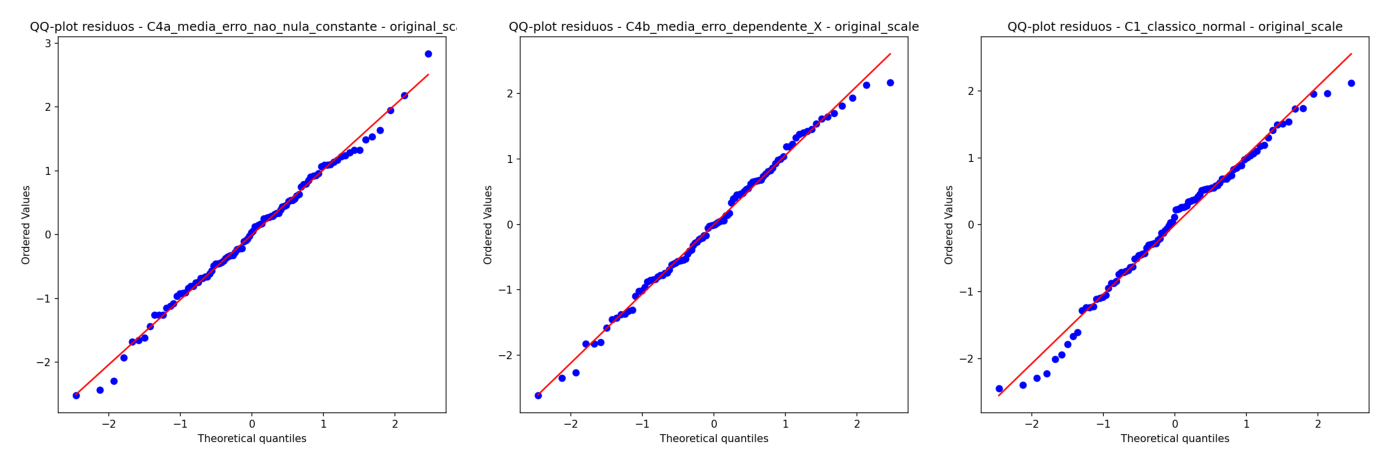

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes[0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4a_media_erro_nao_nula_constante_n100_original_scale_qqplot_residuos.png'))
axes[0].axis('off')
axes[1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4b_media_erro_dependente_X_n100_original_scale_qqplot_residuos.png'))
axes[1].axis('off')
axes[2].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_qqplot_residuos.png'))
axes[2].axis('off')
plt.tight_layout()
plt.show()

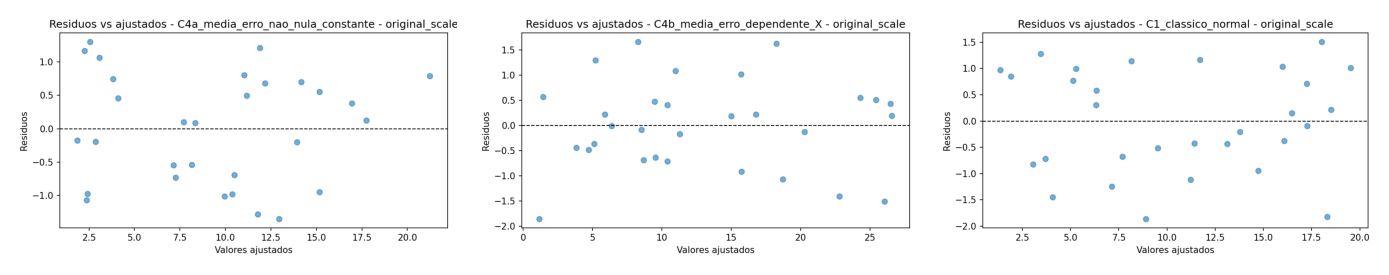

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes[0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4a_media_erro_nao_nula_constante_n30_original_scale_residuos_vs_ajustados.png'))
axes[0].axis('off')
axes[1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C4b_media_erro_dependente_X_n30_original_scale_residuos_vs_ajustados.png'))
axes[1].axis('off')
axes[2].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n30_original_scale_residuos_vs_ajustados.png'))
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Cenário 5: Erros Correlacionados (Estrutura AR1)
Neste cenário, muda apenas a dependência serial dos erros. A média continua próxima de zero e a distribuição marginal permanece comparável à do cenário clássico, mas agora os erros seguem um processo autorregressivo de ordem 1, $\epsilon_i = \rho\epsilon_{i-1} + u_i$. Com $\rho = 0.7$, a comparação com C1 deve se concentrar em erros-padrão, intervalos de confiança e testes.
O objetivo é verificar se o MRLS continua produzindo estimativas pontuais aceitáveis, mesmo quando a inferência é afetada pela autocorrelação.

In [91]:
# Filtrando o Cenário 5 para comparação com o Clássico
df_c5 = df_metrics[
    (df_metrics["scenario_label"].isin(["C1_classico_normal", "C5_erros_correlacionados_ar1"])) & 
    (df_metrics["model"] == "original_scale")
]

display(df_c5.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter", "bias", "variance", "coverage"]])

,scenario_label,n,parameter,bias,variance,coverage
4,C1_classico_normal,30,beta0,-0.020006,0.140086,0.935
5,C1_classico_normal,30,beta1,0.003081,0.004391,0.950
6,C1_classico_normal,100,beta0,0.002656,0.044675,0.957
7,C1_classico_normal,100,beta1,-0.000049,0.001210,0.958
0,C5_erros_correlacionados_ar1,30,beta0,0.002852,0.223276,0.805
1,C5_erros_correlacionados_ar1,30,beta1,0.000375,0.003564,0.949
2,C5_erros_correlacionados_ar1,100,beta0,0.005774,0.079527,0.802
3,C5_erros_correlacionados_ar1,100,beta1,-0.000822,0.001246,0.958


### Avaliação
#### Variabilidade e Erros-Padrão
Ao analisar a tabela, a leitura principal deve ser feita em relação ao cenário clássico:
- O ponto central não é viés, e sim o aumento da incerteza inferencial. Em presença de autocorrelação, os erros-padrão usuais tendem a ficar subestimados.
- Isso explica por que os intervalos ficam estreitos demais e a cobertura cai em relação a C1.
- O efeito do tamanho da amostra é importante: com n=100 a distorção fica mais visível porque as estimativas se estabilizam e o problema de subestimação do erro-padrão aparece com mais clareza.

,scenario_label,n,parameter,mean_hat,bias,variance,mse
4,C1_classico_normal,30,beta0,0.979994,-0.020006,0.140086,0.140347
5,C1_classico_normal,30,beta1,2.003081,0.003081,0.004391,0.004397
6,C1_classico_normal,100,beta0,1.002656,0.002656,0.044675,0.044637
7,C1_classico_normal,100,beta1,1.999951,-0.000049,0.001210,0.001209
0,C5_erros_correlacionados_ar1,30,beta0,1.002852,0.002852,0.223276,0.223061
1,C5_erros_correlacionados_ar1,30,beta1,2.000375,0.000375,0.003564,0.003560
2,C5_erros_correlacionados_ar1,100,beta0,1.005774,0.005774,0.079527,0.079481
3,C5_erros_correlacionados_ar1,100,beta1,1.999178,-0.000822,0.001246,0.001246


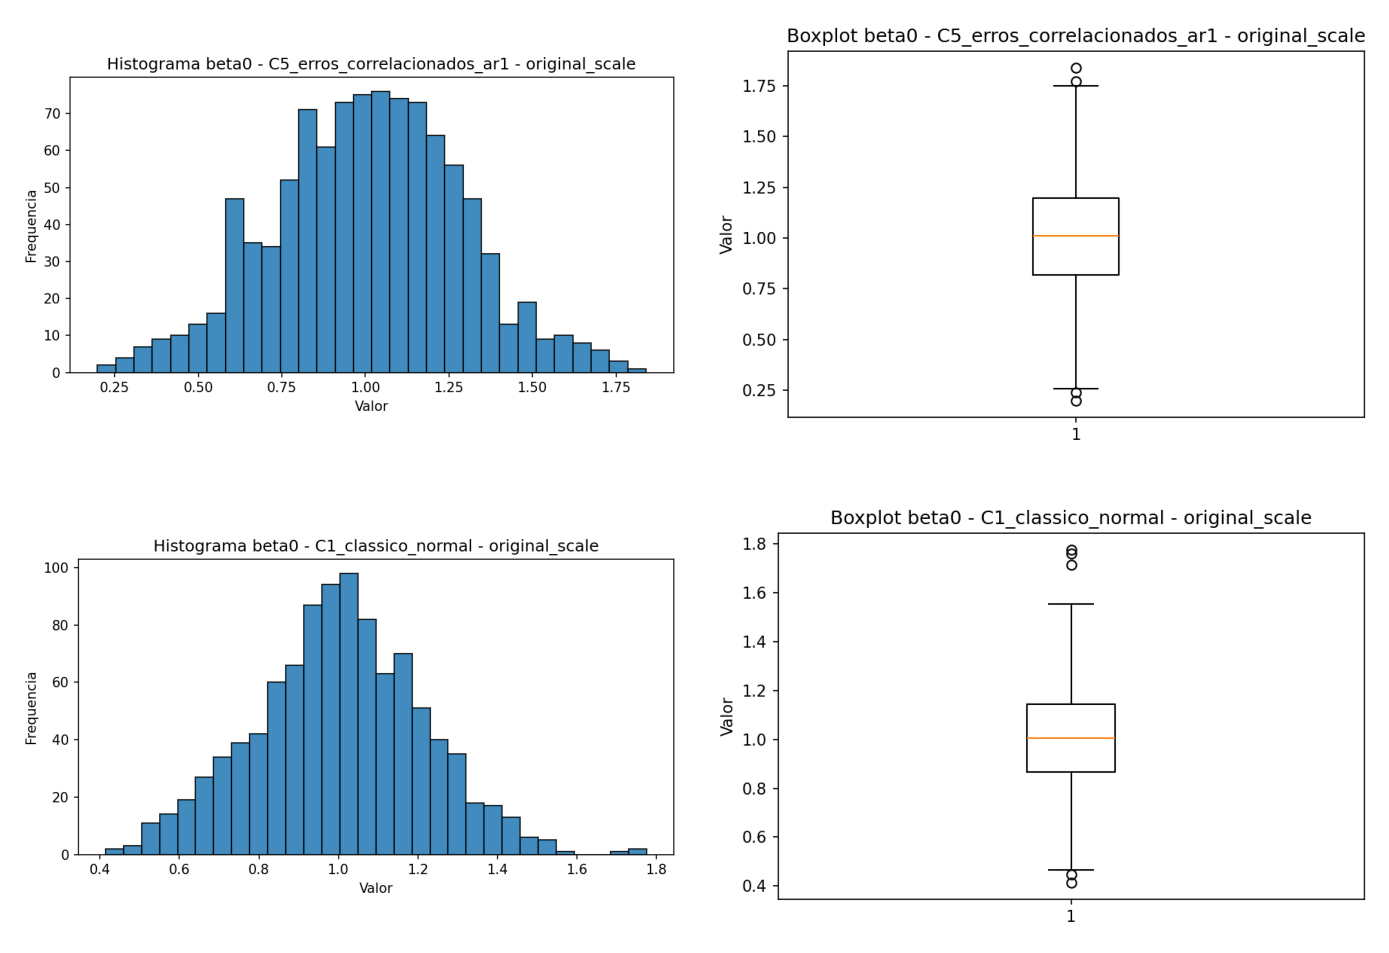

In [102]:
display(df_c5.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter","mean_hat", "bias", "variance", "mse"]])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_hist_beta0.png'))
axes[0][0].axis('off')
axes[0][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_boxplot_beta0.png'))
axes[0][1].axis('off')
axes[1][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_hist_beta0.png'))
axes[1][0].axis('off')
axes[1][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_boxplot_beta0.png'))
axes[1][1].axis('off')
plt.tight_layout()
plt.show()

#### Cobertura dos Intervalos e Comportamento dos Testes
- A queda de cobertura em relação ao cenário clássico mostra que os intervalos construídos com erros-padrão usuais ficam mal calibrados quando há autocorrelação.
- O tamanho do teste tende a ficar inflado porque a dependência serial viola a suposição de independência usada na inferência padrão.
- A interpretação correta é inferencial: o MRLS pode continuar razoável para estimar a tendência média, mas não para quantificar incerteza sem correção dos erros-padrão.

In [96]:
display(df_c5.sort_values(by=["scenario_label", "n", "parameter"])[["scenario_label", "n", "parameter", "coverage", "size_h0", "power_h1"]])

,scenario_label,n,parameter,coverage,size_h0,power_h1
4,C1_classico_normal,30,beta0,0.935,NaN,NaN
5,C1_classico_normal,30,beta1,0.950,0.051,1.0
6,C1_classico_normal,100,beta0,0.957,NaN,NaN
7,C1_classico_normal,100,beta1,0.958,0.052,1.0
0,C5_erros_correlacionados_ar1,30,beta0,0.805,NaN,NaN
1,C5_erros_correlacionados_ar1,30,beta1,0.949,0.040,1.0
2,C5_erros_correlacionados_ar1,100,beta0,0.802,NaN,NaN
3,C5_erros_correlacionados_ar1,100,beta1,0.958,0.056,1.0


#### Diagnóstico e Correção:
- **QQ-Plot dos Resíduos**: O QQ-plot não é o diagnóstico principal aqui, porque a autocorrelação não altera necessariamente a distribuição marginal dos erros. Ele pode parecer aceitável e ainda assim a inferência estar errada.
- **Resíduos vs Ajustados**: Também tem poder limitado para detectar dependência serial. Para este cenário, a evidência relevante está na comparação da cobertura, do tamanho do teste e dos erros-padrão com o cenário clássico.
- **Correção**: Em uma análise aplicada, seria apropriado usar erros-padrão robustos à autocorrelação ou modelar explicitamente a estrutura AR1.

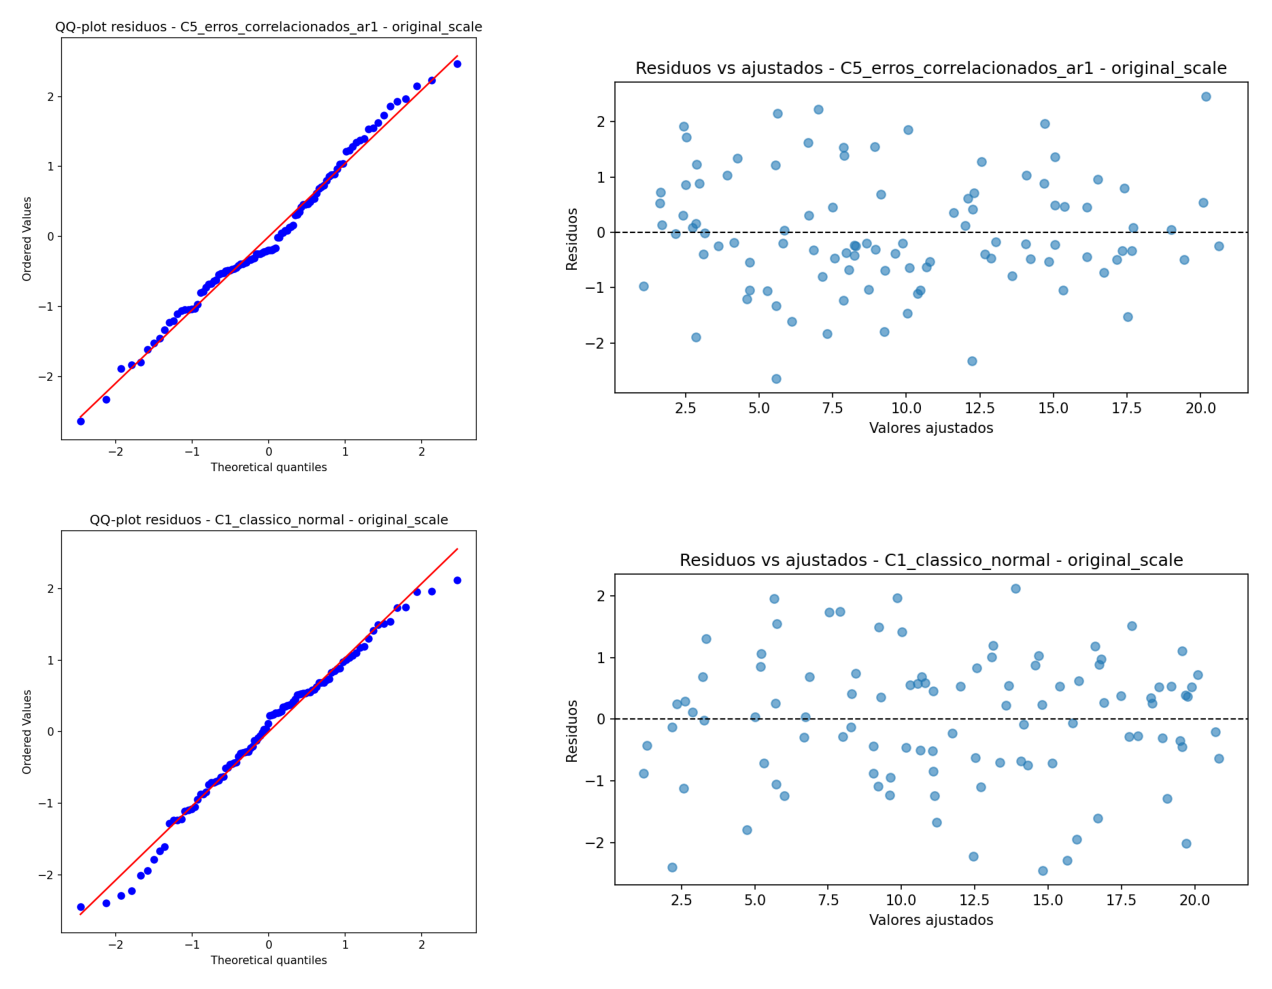

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_qqplot_residuos.png'))
axes[0][0].axis('off')
axes[0][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_residuos_vs_ajustados.png'))
axes[0][1].axis('off')
axes[1][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_qqplot_residuos.png'))
axes[1][0].axis('off')
axes[1][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_residuos_vs_ajustados.png'))
axes[1][1].axis('off')
plt.tight_layout()
plt.show()

## Cenário 6: Relação Exponencial e Transformação Logarítmica
Neste cenário, muda a forma funcional. A geração original segue uma relação exponencial, $Y_i = \exp(\beta_0 + \beta_1 X_i)\cdot \eta_i$, e por isso o ajuste na escala original é comparado diretamente com o ajuste após a transformação logarítmica.
A análise precisa deixar explícito o antes e o depois: no modelo original, a reta é mal especificada; no modelo log-transformado, a relação volta a ser aproximadamente linear e a inferência melhora de forma substancial.

In [106]:
# Filtrando os resultados do Cenário 6 para as duas formas de ajuste
df_c6 = df_metrics[df_metrics["scenario_label"].isin(["C6_relacao_exponencial_lognormal", "C1_classico_normal"])]

# Exibindo métricas de viés, variância e cobertura para os dois modelos
display(df_c6.sort_values(by=["scenario_label", "n", "model", "parameter"])[["scenario_label", "model", "n", "parameter", "bias", "variance", "mse", "coverage"]])

,scenario_label,model,n,parameter,bias,variance,mse,coverage
4,C1_classico_normal,original_scale,30,beta0,-2.000603e-02,1.400864e-01,1.403465e-01,0.935
5,C1_classico_normal,original_scale,30,beta1,3.080984e-03,4.391410e-03,4.396511e-03,0.950
6,C1_classico_normal,original_scale,100,beta0,2.656298e-03,4.467496e-02,4.463734e-02,0.957
7,C1_classico_normal,original_scale,100,beta1,-4.911590e-05,1.210126e-03,1.208918e-03,0.958
8,C6_relacao_exponencial_lognormal,log_transform,30,beta0,-3.080652e-03,1.545938e-02,1.545341e-02,0.953
9,C6_relacao_exponencial_lognormal,log_transform,30,beta1,1.215876e-04,6.546366e-04,6.539968e-04,0.961
10,C6_relacao_exponencial_lognormal,original_scale,30,beta0,-6.751592e+07,2.855783e+14,4.843692e+15,1.000
11,C6_relacao_exponencial_lognormal,original_scale,30,beta1,2.372677e+07,3.273563e+13,5.956625e+14,0.000
12,C6_relacao_exponencial_lognormal,log_transform,100,beta0,3.814486e-04,8.540075e-03,8.531680e-03,0.939
13,C6_relacao_exponencial_lognormal,log_transform,100,beta1,2.202896e-04,2.251917e-04,2.250151e-04,0.954


### Avaliação
#### Impacto da Não-Linearidade (Escala Original)
- Aqui o modelo de referência é C1. A comparação mostra que a reta ajustada na escala original não acompanha a curvatura dos dados e, por isso, os vieses crescem de forma absurda.
- As métricas usadas para mostrar a falha são viés, variância e cobertura, além dos gráficos de resíduos e do QQ-plot.
- A conclusão é que o MRLS, sem transformação, não representa bem a estrutura dos dados exponenciais.

,scenario_label,model,n,parameter,mean_hat,bias,variance,mse,coverage
4,C1_classico_normal,original_scale,30,beta0,9.799940e-01,-2.000603e-02,1.400864e-01,1.403465e-01,0.935
5,C1_classico_normal,original_scale,30,beta1,2.003081e+00,3.080984e-03,4.391410e-03,4.396511e-03,0.950
6,C1_classico_normal,original_scale,100,beta0,1.002656e+00,2.656298e-03,4.467496e-02,4.463734e-02,0.957
7,C1_classico_normal,original_scale,100,beta1,1.999951e+00,-4.911590e-05,1.210126e-03,1.208918e-03,0.958
8,C6_relacao_exponencial_lognormal,log_transform,30,beta0,9.969193e-01,-3.080652e-03,1.545938e-02,1.545341e-02,0.953
9,C6_relacao_exponencial_lognormal,log_transform,30,beta1,2.000122e+00,1.215876e-04,6.546366e-04,6.539968e-04,0.961
10,C6_relacao_exponencial_lognormal,original_scale,30,beta0,-6.751592e+07,-6.751592e+07,2.855783e+14,4.843692e+15,1.000
11,C6_relacao_exponencial_lognormal,original_scale,30,beta1,2.372677e+07,2.372677e+07,3.273563e+13,5.956625e+14,0.000
12,C6_relacao_exponencial_lognormal,log_transform,100,beta0,1.000381e+00,3.814486e-04,8.540075e-03,8.531680e-03,0.939
13,C6_relacao_exponencial_lognormal,log_transform,100,beta1,2.000220e+00,2.202896e-04,2.251917e-04,2.250151e-04,0.954


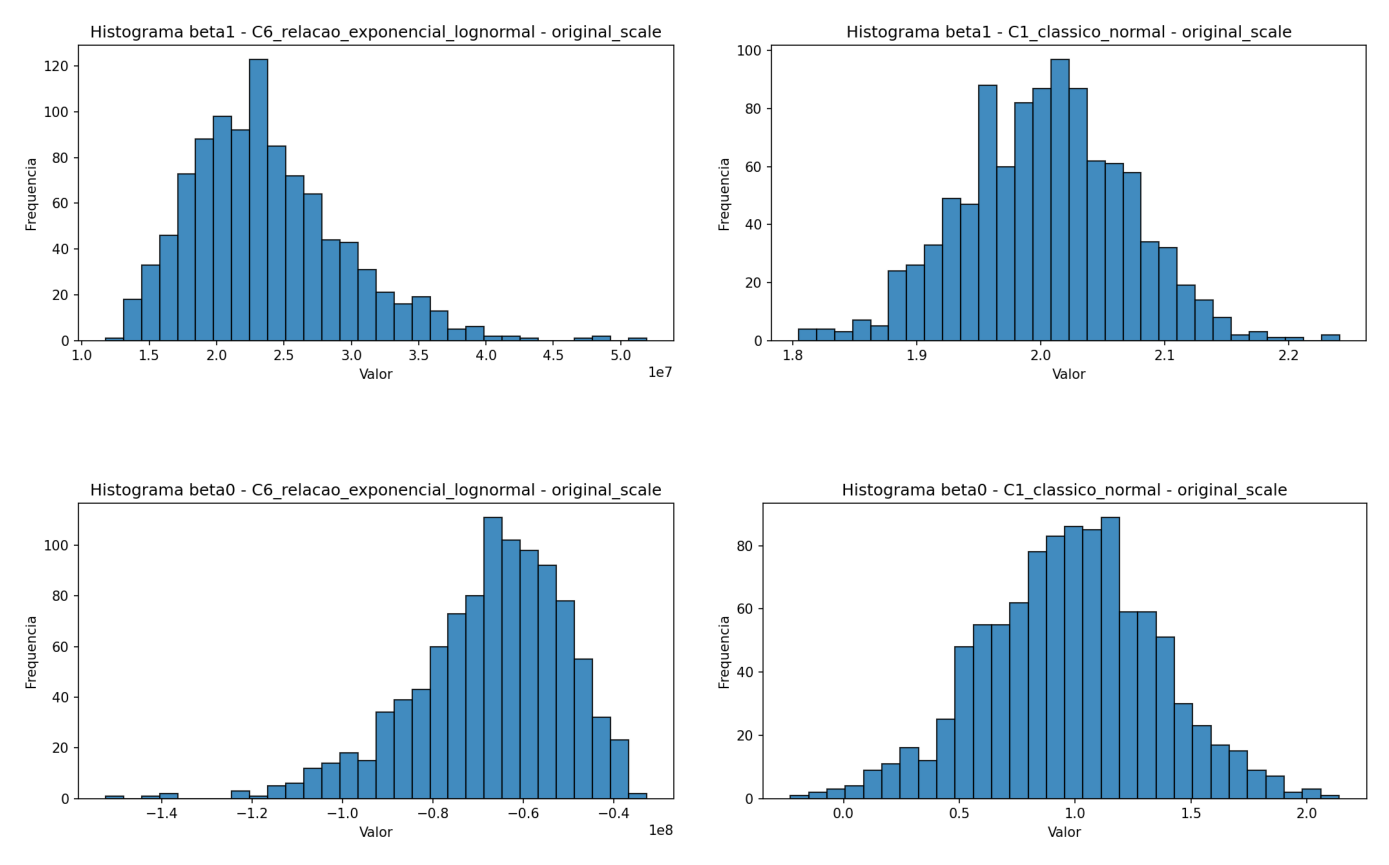

In [113]:
display(df_c6.sort_values(by=["scenario_label", "n", "model", "parameter"])[["scenario_label", "model", "n", "parameter", "mean_hat", "bias", "variance", "mse", "coverage"]])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n30_original_scale_hist_beta1.png'))
axes[0][0].axis('off')
axes[0][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n30_original_scale_hist_beta1.png'))
axes[0][1].axis('off')
axes[1][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n30_original_scale_hist_beta0.png'))
axes[1][0].axis('off')
axes[1][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C1_classico_normal_n30_original_scale_hist_beta0.png'))
axes[1][1].axis('off')
plt.tight_layout()
plt.show()

#### A Eficácia da Transformação (Log-Transform)
- Depois da transformação, os mesmos dados passam a ser analisados em uma escala na qual a relação entre X e Y se aproxima da linearidade.
- A comparação com o caso original mostra melhora clara em viés, variância e cobertura, especialmente para n=100.
- A mensagem principal é que a transformação corrige a forma funcional e devolve ao MRLS um comportamento compatível com suas suposições.

,scenario_label,model,n,bias,parameter,coverage,size_h0,power_h1
4,C1_classico_normal,original_scale,30,-2.000603e-02,beta0,0.935,NaN,NaN
5,C1_classico_normal,original_scale,30,3.080984e-03,beta1,0.950,0.051,1.0
6,C1_classico_normal,original_scale,100,2.656298e-03,beta0,0.957,NaN,NaN
7,C1_classico_normal,original_scale,100,-4.911590e-05,beta1,0.958,0.052,1.0
8,C6_relacao_exponencial_lognormal,log_transform,30,-3.080652e-03,beta0,0.953,NaN,NaN
9,C6_relacao_exponencial_lognormal,log_transform,30,1.215876e-04,beta1,0.961,0.047,1.0
10,C6_relacao_exponencial_lognormal,original_scale,30,-6.751592e+07,beta0,1.000,NaN,NaN
11,C6_relacao_exponencial_lognormal,original_scale,30,2.372677e+07,beta1,0.000,0.061,1.0
12,C6_relacao_exponencial_lognormal,log_transform,100,3.814486e-04,beta0,0.939,NaN,NaN
13,C6_relacao_exponencial_lognormal,log_transform,100,2.202896e-04,beta1,0.954,0.057,1.0


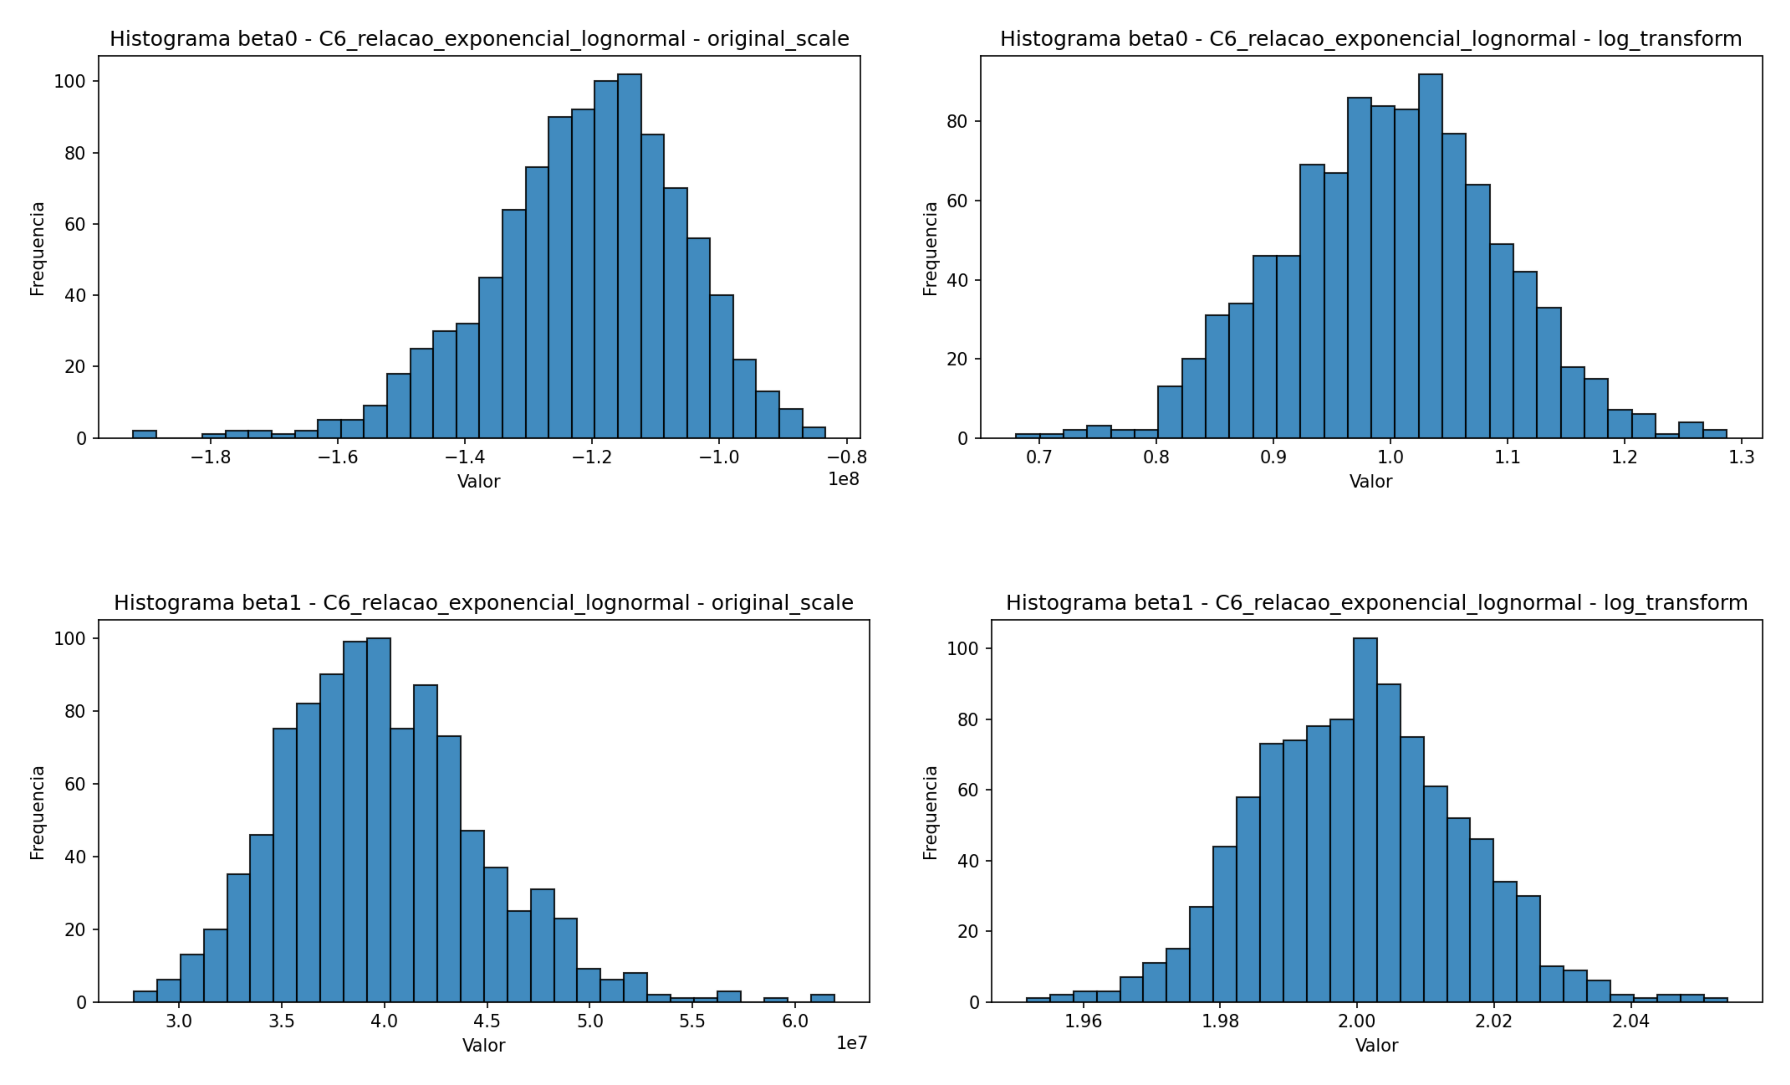

In [115]:
display(df_c6.sort_values(by=["scenario_label", "n", "model", "parameter"])[["scenario_label", "model", "n", "bias", "parameter", "coverage", "size_h0", "power_h1"]])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_hist_beta0.png'))
axes[0][0].axis('off')
axes[0][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_log_transform_hist_beta0.png'))
axes[0][1].axis('off')
axes[1][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_hist_beta1.png'))
axes[1][0].axis('off')
axes[1][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_log_transform_hist_beta1.png'))
axes[1][1].axis('off')
plt.tight_layout()
plt.show()

#### Diagnóstico Gráfico: O Poder da Transformação
- **Escala Original:** Os resíduos vs ajustados mostram curvatura e variância crescente, o que indica má especificação e heterocedasticidade.
- **Escala Logarítmica:** Após a transformação, os resíduos ficam mais estáveis e o QQ-plot se aproxima da reta de normalidade.
- **Correção:** A transformação logarítmica é a mudança-chave que separa o modelo mal ajustado do modelo bem especificado.

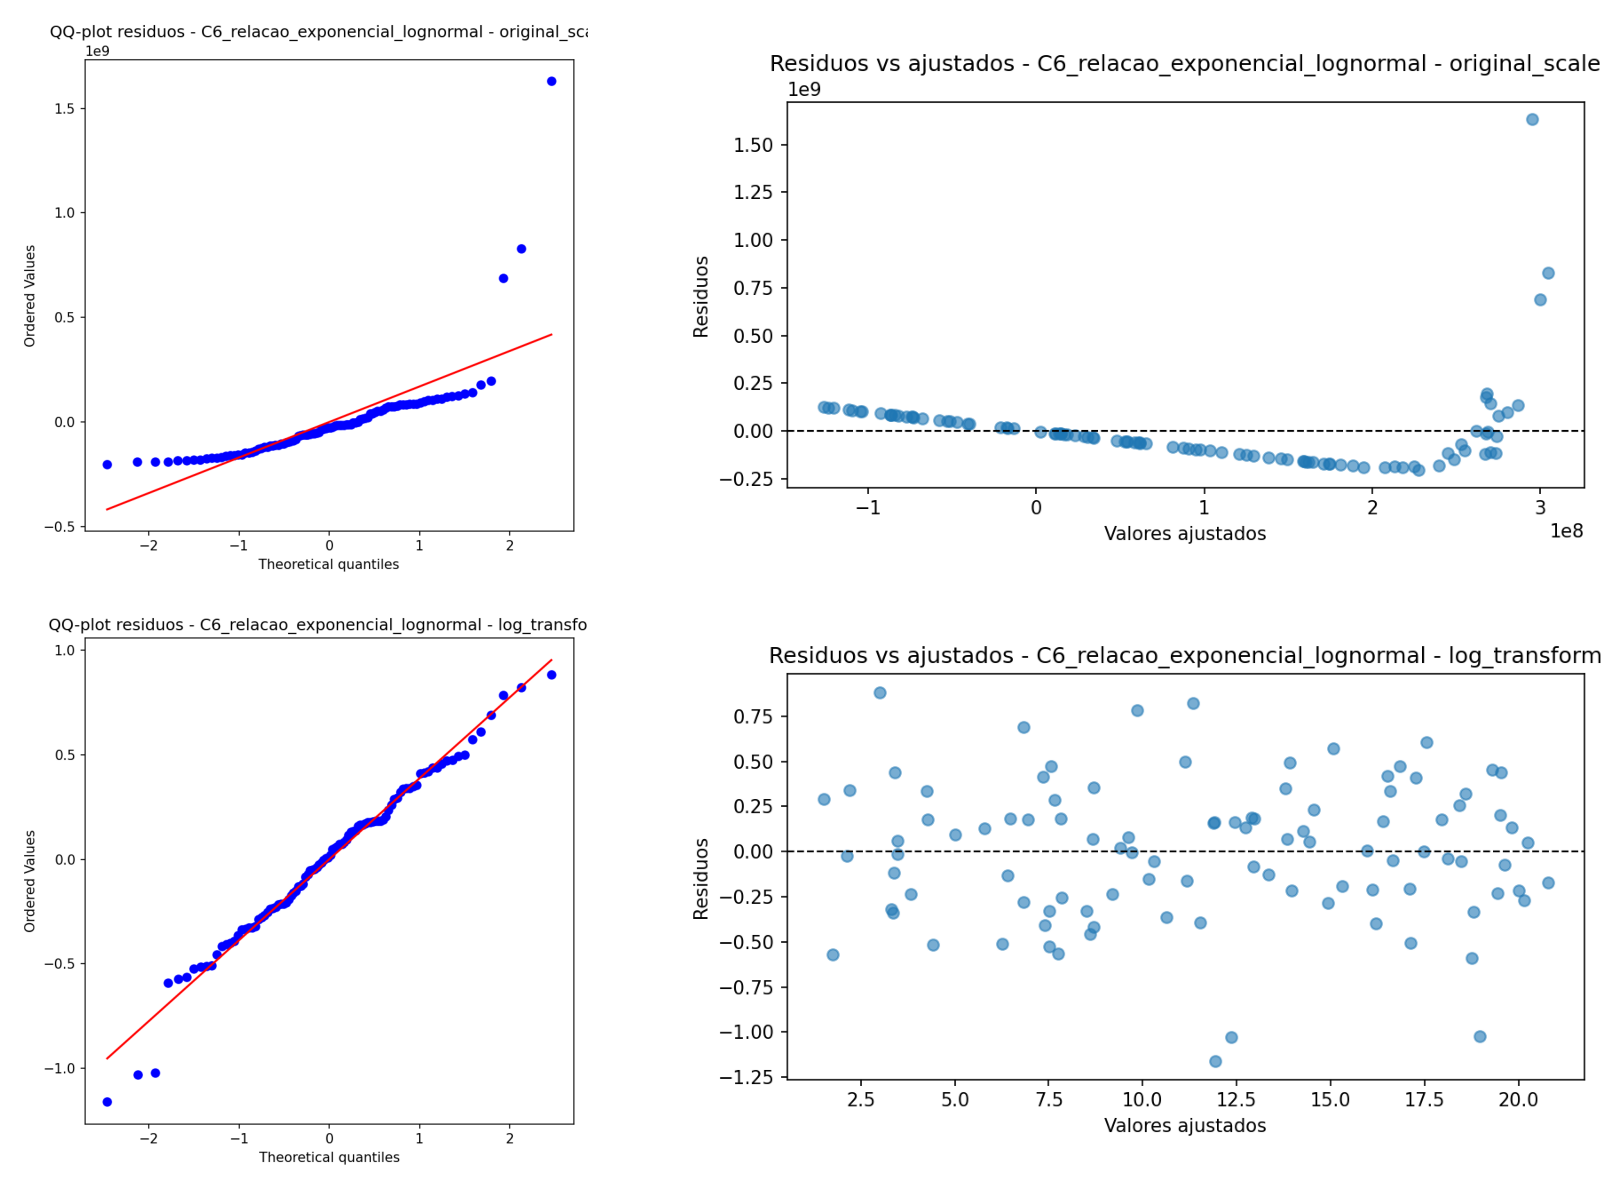

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_qqplot_residuos.png'))
axes[0][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_residuos_vs_ajustados.png'))
axes[1][0].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_log_transform_qqplot_residuos.png'))
axes[1][1].imshow(plt.imread(f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_log_transform_residuos_vs_ajustados.png'))
axes[0][0].axis('off')
axes[0][1].axis('off')
axes[1][0].axis('off')
axes[1][1].axis('off')
plt.tight_layout()
plt.show()